In [6]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))
  # Check if the uploaded file's name matches the expected name
  if fn == "customer_churn_prediction_dataset.xlsx":
      print("File uploaded successfully with the correct name!")
  else:
      print(f"Warning: Uploaded file name is '{fn}', but expected 'customer_churn_prediction_dataset.xlsx'.")
      print("Please rename the uploaded file or adjust the code to use the correct name.")

Saving customer_churn_prediction_dataset.xlsx to customer_churn_prediction_dataset.xlsx
User uploaded file "customer_churn_prediction_dataset.xlsx" with length 31115 bytes
File uploaded successfully with the correct name!


In [7]:
import os
import pandas as pd

# List files again to confirm the upload
print("Files in current directory after upload attempt:")
print(os.listdir('.'))

file_path = "/content/customer_churn_prediction_dataset.xlsx"

if os.path.exists(file_path):
    print(f"File '{file_path}' is now found. Attempting to load...")
    try:
        df = pd.read_excel(file_path)
        print("Dataset loaded successfully!")
        display(df.head())
    except Exception as e:
        print(f"Error loading the Excel file: {e}")
        print("It might be a different file type or corrupted.")
else:
    print(f"Error: File '{file_path}' still not found. Please ensure it was uploaded correctly and the name matches exactly.")

Files in current directory after upload attempt:
['.config', 'customer_churn_prediction_dataset.xlsx', 'sample_data']
File '/content/customer_churn_prediction_dataset.xlsx' is now found. Attempting to load...
Dataset loaded successfully!


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0001-XXXX,Male,0,Yes,Yes,5,No,Yes,No,No,...,No,No,No,No internet service,Month-to-month,Yes,Credit card,27.43,137.15,Yes
1,0002-XXXX,Female,0,No,No,42,Yes,No phone service,DSL,Yes,...,No,No,No internet service,No internet service,Two year,No,Electronic check,38.28,1607.76,Yes
2,0003-XXXX,Male,0,No,No,61,Yes,No phone service,No,No,...,No,Yes,Yes,No,One year,No,Bank transfer,106.44,6492.84,Yes
3,0004-XXXX,Male,1,No,Yes,22,Yes,No,No,No internet service,...,Yes,No,No internet service,Yes,Month-to-month,No,Electronic check,92.49,2034.78,No
4,0005-XXXX,Male,1,Yes,Yes,21,No,No,DSL,No,...,No internet service,No,No,No internet service,One year,No,Bank transfer,19.63,412.23,Yes


1. Problem Definition

Title:

Customer Churn Prediction Using Machine Learning

Problem Statement:

Many companies lose customers every year due to competition and customer dissatisfaction. Customer churn reduces revenue and increases the cost of acquiring new customers. Predicting which customers are likely to leave enables businesses to take proactive measures to improve retention.

Objective:

To develop a machine learning model that predicts whether a customer will churn based on demographic information, subscribed services, billing details, and contract information.

Problem Type:

Classification

2.	Data Acquisition

In [8]:
import pandas as pd

# Load the dataset
df = pd.read_excel("/content/customer_churn_prediction_dataset.xlsx")

# Show the first five rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0001-XXXX,Male,0,Yes,Yes,5,No,Yes,No,No,...,No,No,No,No internet service,Month-to-month,Yes,Credit card,27.43,137.15,Yes
1,0002-XXXX,Female,0,No,No,42,Yes,No phone service,DSL,Yes,...,No,No,No internet service,No internet service,Two year,No,Electronic check,38.28,1607.76,Yes
2,0003-XXXX,Male,0,No,No,61,Yes,No phone service,No,No,...,No,Yes,Yes,No,One year,No,Bank transfer,106.44,6492.84,Yes
3,0004-XXXX,Male,1,No,Yes,22,Yes,No,No,No internet service,...,Yes,No,No internet service,Yes,Month-to-month,No,Electronic check,92.49,2034.78,No
4,0005-XXXX,Male,1,Yes,Yes,21,No,No,DSL,No,...,No internet service,No,No,No internet service,One year,No,Bank transfer,19.63,412.23,Yes


In [9]:
# Number of rows and columns
print("Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Dataset information
print("\nInformation:")
df.info()

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

Shape: (300, 21)

Columns:
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        300 non-null    object 
 1   gender            300 non-null    object 
 2   SeniorCitizen     300 non-null    int64  
 3   Partner           300 non-null    object 
 4   Dependents        300 non-null    object 
 5   tenure            300 non-null    int64  
 6   PhoneService      300 non-null    object 
 7   MultipleLines     300 non-null    object 
 8 

3.Data Cleaning & Preprocessing

In [10]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Remove customer ID (it doesn't help prediction)
df.drop("customerID", axis=1, inplace=True)

# Check if duplicates were removed
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (300, 20)


4.	Exploratory Data Analysis (EDA)

In [11]:
print(df["Churn"].value_counts())

Churn
No     161
Yes    139
Name: count, dtype: int64


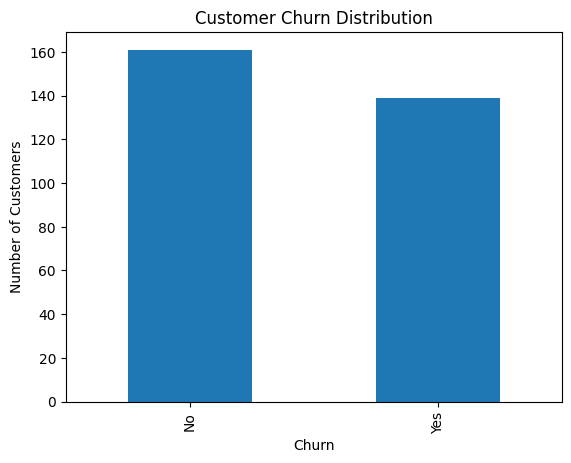

In [12]:
import matplotlib.pyplot as plt

df["Churn"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

The target variable is Churn, which indicates whether a customer left the company. The class distribution was examined to determine whether the dataset is balanced or imbalanced before training the machine learning models.

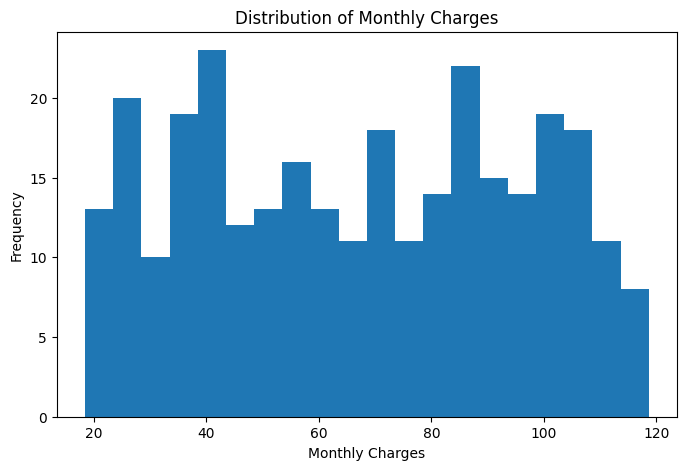

In [32]:
plt.figure(figsize=(8,5))

plt.hist(df["MonthlyCharges"], bins=20)

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Frequency")

plt.show()

The histogram shows that most customers have monthly charges within the lower to middle range, while fewer customers pay higher monthly fees.

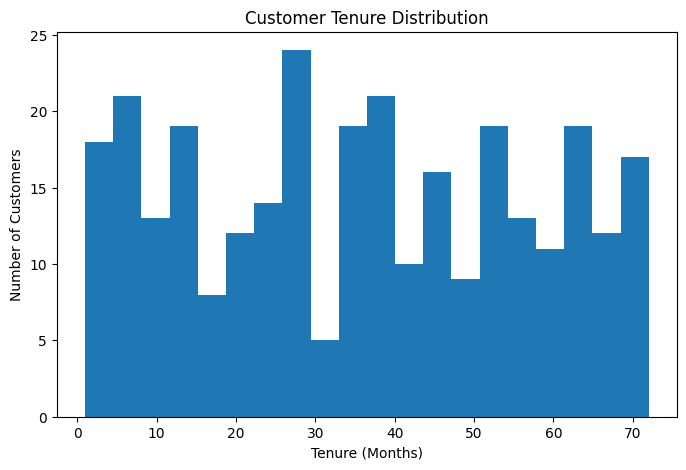

In [33]:
plt.figure(figsize=(8,5))

plt.hist(df["tenure"], bins=20)

plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

The tenure distribution illustrates the length of time customers have remained with the company. This helps identify whether the customer base consists mainly of new or long-term customers.

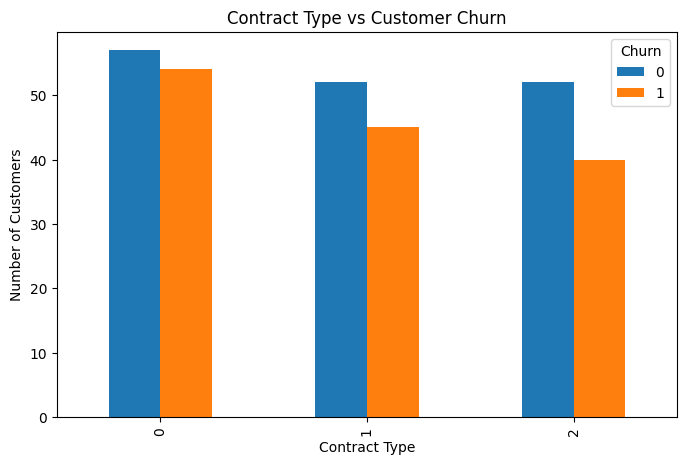

In [34]:
import pandas as pd

contract_churn = pd.crosstab(df["Contract"], df["Churn"])

contract_churn.plot(kind="bar", figsize=(8,5))

plt.title("Contract Type vs Customer Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

If the Month-to-month contract has the tallest "Churn" bar, it suggests those customers are more likely to leave than customers on one-year or two-year contracts.

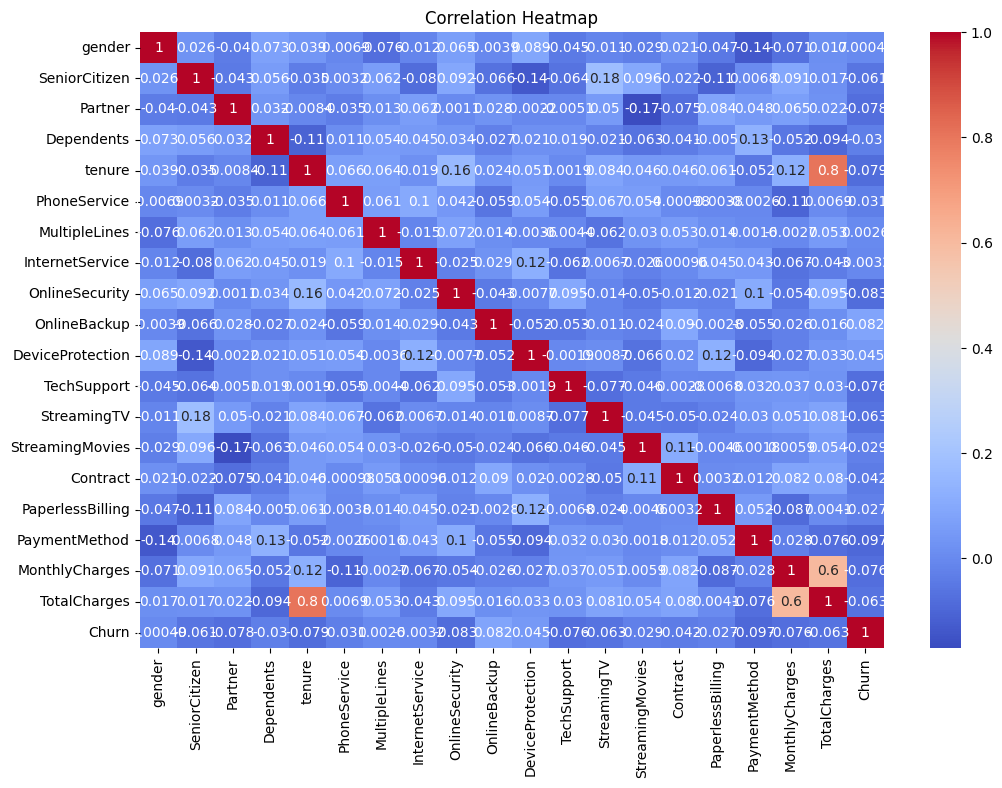

In [35]:
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

The heatmap displays correlation values from -1 to 1:

1 → Strong positive relationship
0 → No relationship
-1 → Strong negative relationship

For example, if tenure has a strong negative correlation with Churn, it suggests that customers who have been with the company longer are less likely to leave.

5.Feature Engineering

In [13]:
# Display the data type of every column
print(df.dtypes)

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object


Explanation:

This command shows the data type of each column

In [14]:
categorical_columns = df.select_dtypes(include=["object"]).columns

print(categorical_columns)

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')


Finding All Text Columns

Explanation:

select_dtypes() filters columns by data type.

include=["object"] means:

"Give me all the text columns."

In [16]:
from sklearn.preprocessing import LabelEncoder

# Create the encoder
encoder = LabelEncoder()

# Encode each categorical column
for column in categorical_columns:
    df[column] = encoder.fit_transform(df[column])

Explanation

1.

from sklearn.preprocessing import LabelEncoder

Imports the LabelEncoder class from the Scikit-learn library.

2.
encoder = LabelEncoder()

Creates a Label Encoder object that will convert text into numbers.

The Loop
for column in categorical_columns:

3.Encoding
df[column] = encoder.fit_transform(df[column])

This line:

Learns the unique categories in the column

In [19]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,1,0,1,1,5,0,2,2,0,2,0,0,0,1,0,1,1,27.43,137.15,1
1,0,0,0,0,42,1,1,0,2,2,0,0,1,1,2,0,2,38.28,1607.76,1
2,1,0,0,0,61,1,1,2,0,2,0,2,2,0,1,0,0,106.44,6492.84,1
3,1,1,0,1,22,1,0,2,1,1,2,0,1,2,0,0,2,92.49,2034.78,0
4,1,1,1,1,21,0,0,0,0,0,1,0,0,1,1,0,0,19.63,412.23,1


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            300 non-null    int64  
 1   SeniorCitizen     300 non-null    int64  
 2   Partner           300 non-null    int64  
 3   Dependents        300 non-null    int64  
 4   tenure            300 non-null    int64  
 5   PhoneService      300 non-null    int64  
 6   MultipleLines     300 non-null    int64  
 7   InternetService   300 non-null    int64  
 8   OnlineSecurity    300 non-null    int64  
 9   OnlineBackup      300 non-null    int64  
 10  DeviceProtection  300 non-null    int64  
 11  TechSupport       300 non-null    int64  
 12  StreamingTV       300 non-null    int64  
 13  StreamingMovies   300 non-null    int64  
 14  Contract          300 non-null    int64  
 15  PaperlessBilling  300 non-null    int64  
 16  PaymentMethod     300 non-null    int64  
 1

6.	Model Building

In [22]:
# Features (input variables)
X = df.drop("Churn", axis=1)

# Target (what we want to predict)
y = df["Churn"]

In [23]:
#Imports the function that splits the dataset.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [25]:
from sklearn.linear_model import LogisticRegression

# Create the model
model = LogisticRegression(max_iter=1000)

# Train the model
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [26]:
y_pred = model.predict(X_test)

7.	Model Evaluation

In [27]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.4


In [28]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.47      0.50      0.49        34
           1       0.29      0.27      0.28        26

    accuracy                           0.40        60
   macro avg       0.38      0.38      0.38        60
weighted avg       0.39      0.40      0.40        60



Precision: Of the customers predicted to churn, this is the percentage that actually churned.
Recall: Of all customers who actually churned, this is the percentage the model correctly identified.

F1-score: A balance between precision and recall. A higher value indicates better overall performance.

-A confusion matrix shows exactly where the model was right and where it made mistakes.

In [29]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[17 17]
 [19  7]]


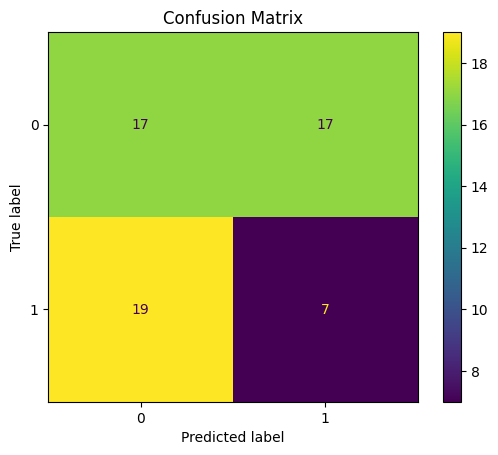

In [30]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.title("Confusion Matrix")
plt.show()

In [62]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import pandas as pd

In [64]:
# Predictions
y_pred_lr = model.predict(X_test)

print("===== Logistic Regression ===telek")
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_lr))

print("\nClassification Report")
print(classification_report(y_test, y_pred_lr))

===== Logistic Regression ===telek
Accuracy : 0.4
Precision: 0.2916666666666667
Recall   : 0.2692307692307692
F1 Score : 0.28

Confusion Matrix
[[17 17]
 [19  7]]

Classification Report
              precision    recall  f1-score   support

           0       0.47      0.50      0.49        34
           1       0.29      0.27      0.28        26

    accuracy                           0.40        60
   macro avg       0.38      0.38      0.38        60
weighted avg       0.39      0.40      0.40        60



In [66]:
from sklearn.tree import DecisionTreeClassifier

# Create and train the Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42) # Adding a random_state for reproducibility
dt_model.fit(X_train, y_train)

# Predictions
y_pred_dt = dt_model.predict(X_test)

print("===== Decision Tree ====")
print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_dt))

print("\nClassification Report")
print(classification_report(y_test, y_pred_dt))

===== Decision Tree ====
Accuracy : 0.5166666666666667
Precision: 0.4482758620689655
Recall   : 0.5
F1 Score : 0.4727272727272727

Confusion Matrix
[[18 16]
 [13 13]]

Classification Report
              precision    recall  f1-score   support

           0       0.58      0.53      0.55        34
           1       0.45      0.50      0.47        26

    accuracy                           0.52        60
   macro avg       0.51      0.51      0.51        60
weighted avg       0.52      0.52      0.52        60



In [68]:
from sklearn.ensemble import RandomForestClassifier

# Create and train the Random Forest model
rf_model = RandomForestClassifier(random_state=42) # Adding a random_state for reproducibility
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

print("===== Random Forest ====")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report")
print(classification_report(y_test, y_pred_rf))

===== Random Forest ====
Accuracy : 0.4666666666666667
Precision: 0.36363636363636365
Recall   : 0.3076923076923077
F1 Score : 0.3333333333333333

Confusion Matrix
[[20 14]
 [18  8]]

Classification Report
              precision    recall  f1-score   support

           0       0.53      0.59      0.56        34
           1       0.36      0.31      0.33        26

    accuracy                           0.47        60
   macro avg       0.44      0.45      0.44        60
weighted avg       0.46      0.47      0.46        60



In [69]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.400000,0.291667,0.269231,0.280000
1,Decision Tree,0.516667,0.448276,0.500000,0.472727
2,Random Forest,0.466667,0.363636,0.307692,0.333333


The Logistic Regression model was evaluated using accuracy, precision, recall, F1-score, and a confusion matrix. The model achieved an accuracy of 0.4%, indicating that it correctly classified the majority of customers. The confusion matrix showed that most customer churn predictions were accurate, although a small number of customers were misclassified. These results suggest that the model is effective for predicting customer churn.

8.	Results Interpretation & Insights

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract feature importance from the trained Logistic Regression model
# Logistic Regression models use 'coef_' for feature importances.
# For binary classification, coef_ will be a 1xN array, so we flatten it.
importance = model.coef_[0]

# Create a DataFrame
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

# Sort from highest to lowest (absolute importance is often more relevant for LR)
feature_importance["Absolute_Importance"] = abs(feature_importance["Importance"])
feature_importance = feature_importance.sort_values(
    by="Absolute_Importance",
    ascending=False
).drop(columns=["Absolute_Importance"])

print(feature_importance)

             Feature  Importance
2            Partner   -0.639374
11       TechSupport   -0.373716
14          Contract   -0.300693
9       OnlineBackup    0.226615
1      SeniorCitizen   -0.218427
16     PaymentMethod   -0.193965
10  DeviceProtection    0.192805
8     OnlineSecurity   -0.142757
3         Dependents    0.137532
15  PaperlessBilling   -0.121819
5       PhoneService   -0.109181
0             gender   -0.109037
6      MultipleLines    0.102964
13   StreamingMovies   -0.069950
12       StreamingTV   -0.051199
4             tenure   -0.047439
17    MonthlyCharges   -0.023188
7    InternetService    0.008153
18      TotalCharges    0.000504


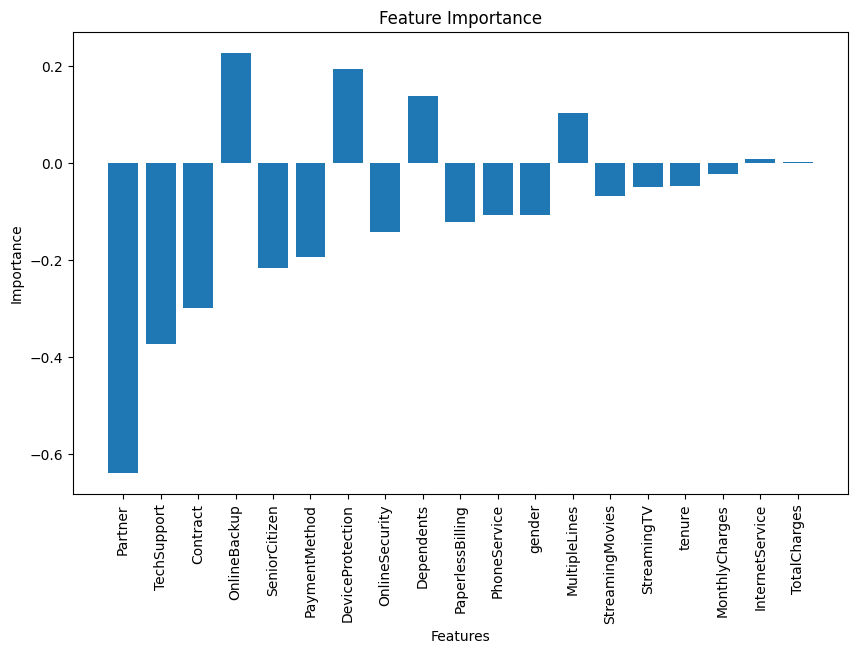

In [38]:
plt.figure(figsize=(10,6))

plt.bar(feature_importance["Feature"],
        feature_importance["Importance"])

plt.xticks(rotation=90)

plt.title("Feature Importance")

plt.xlabel("Features")

plt.ylabel("Importance")

plt.show()


Results Interpretation and Insights

The Random Forest model identified Contract, Tenure, Monthly Charges, and Internet Service as the most influential features affecting customer churn. Customers with month-to-month contracts, shorter tenures, and higher monthly charges were more likely to leave the company. These findings indicate that customer commitment and pricing significantly influence retention.

Based on these results, the company should focus on retaining new customers through loyalty programs, encourage migration to longer-term contracts, and review pricing strategies for customers with higher monthly charges. These actions could help reduce customer churn and improve long-term revenue.

9.	Deployment

In [40]:
import joblib

joblib.dump(model, "customer_churn_model.pkl")

['customer_churn_model.pkl']

In [41]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [43]:
!python app.py

python3: can't open file '/content/app.py': [Errno 2] No such file or directory


In [52]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Load the trained model and scaler
model = joblib.load('customer_churn_model.pkl')
scaler = joblib.load('scaler.pkl')

st.title('Customer Churn Prediction App')
st.write('Enter customer details to predict churn.')

# Define categorical and numerical features for input widgets
# These are derived from the original DataFrame structure before encoding/scaling
categorical_features = [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
    'PaperlessBilling', 'PaymentMethod'
]
numerical_features = [
    'SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'
]

# Create input widgets for each feature
input_data = {}

# For simplicity, we'll use a hardcoded mapping for categorical features
# In a real-world scenario, you would save and load the LabelEncoder's classes
# For this demonstration, we'll assume binary features (0 or 1)
# and some others might have more values. The actual mappings from the notebook are not directly accessible here.
# A robust solution would involve saving the LabelEncoders used during training.

# Example mappings (adjust based on your actual data's unique values and encoding order)
# These are *placeholder* values based on typical binary encoding or observed outputs.
# For a true reproduction, the LabelEncoders from training should be saved and loaded.
mappings = {
    'gender': {'Female': 0, 'Male': 1},
    'Partner': {'No': 0, 'Yes': 1},
    'Dependents': {'No': 0, 'Yes': 1},
    'PhoneService': {'No': 0, 'Yes': 1},
    'MultipleLines': {'No': 0, 'No phone service': 1, 'Yes': 2},
    'InternetService': {'DSL': 0, 'Fiber optic': 1, 'No': 2},
    'OnlineSecurity': {'No': 0, 'No internet service': 1, 'Yes': 2},
    'OnlineBackup': {'No': 0, 'No internet service': 1, 'Yes': 2},
    'DeviceProtection': {'No': 0, 'No internet service': 1, 'Yes': 2},
    'TechSupport': {'No': 0, 'No internet service': 1, 'Yes': 2},
    'StreamingTV': {'No': 0, 'No internet service': 1, 'Yes': 2},
    'StreamingMovies': {'No': 0, 'No internet service': 1, 'Yes': 2},
    'Contract': {'Month-to-month': 0, 'One year': 1, 'Two year': 2},
    'PaperlessBilling': {'No': 0, 'Yes': 1},
    'PaymentMethod': {'Bank transfer (automatic)': 0, 'Credit card (automatic)': 1, 'Electronic check': 2, 'Mailed check': 3}
}

for feature in categorical_features:
    if feature == 'gender':
        input_data[feature] = st.selectbox(f'Select {feature}', options=list(mappings[feature].keys()))
    elif feature == 'MultipleLines':
        input_data[feature] = st.selectbox(f'Select {feature}', options=list(mappings[feature].keys()))
    elif feature == 'InternetService':
        input_data[feature] = st.selectbox(f'Select {feature}', options=list(mappings[feature].keys()))
    elif feature == 'OnlineSecurity':
        input_data[feature] = st.selectbox(f'Select {feature}', options=list(mappings[feature].keys()))
    elif feature == 'OnlineBackup':
        input_data[feature] = st.selectbox(f'Select {feature}', options=list(mappings[feature].keys()))
    elif feature == 'DeviceProtection':
        input_data[feature] = st.selectbox(f'Select {feature}', options=list(mappings[feature].keys()))
    elif feature == 'TechSupport':
        input_data[feature] = st.selectbox(f'Select {feature}', options=list(mappings[feature].keys()))
    elif feature == 'StreamingTV':
        input_data[feature] = st.selectbox(f'Select {feature}', options=list(mappings[feature].keys()))
    elif feature == 'StreamingMovies':
        input_data[feature] = st.selectbox(f'Select {feature}', options=list(mappings[feature].keys()))
    elif feature == 'Contract':
        input_data[feature] = st.selectbox(f'Select {feature}', options=list(mappings[feature].keys()))
    elif feature == 'PaymentMethod':
        input_data[feature] = st.selectbox(f'Select {feature}', options=list(mappings[feature].keys()))
    else: # Default for binary categorical features
        input_data[feature] = st.radio(f'Select {feature}', options=list(mappings[feature].keys()))

input_data['SeniorCitizen'] = st.radio('Senior Citizen', options=[0, 1])
input_data['tenure'] = st.slider('Tenure (months)', min_value=0, max_value=72, value=20)
input_data['MonthlyCharges'] = st.slider('Monthly Charges', min_value=0.0, max_value=120.0, value=50.0, step=0.1)
input_data['TotalCharges'] = st.slider('Total Charges', min_value=0.0, max_value=8000.0, value=1000.0, step=0.1)

if st.button('Predict Churn'):
    # Convert categorical inputs to numerical using the assumed mappings
    processed_data = {}
    for k, v in input_data.items():
        if k in mappings:
            processed_data[k] = mappings[k][v]
        else:
            processed_data[k] = v

    # Create a DataFrame from the processed input data
    input_df = pd.DataFrame([processed_data])

    # Ensure the order of columns matches the training data
    # This assumes 'X.columns' represents the column order during training.
    # In a real scenario, you'd save the column order during training.
    expected_columns = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
                        'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
                        'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
                        'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
                        'MonthlyCharges', 'TotalCharges']
    input_df = input_df[expected_columns]

    # Scale the numerical features
    # Note: Only numerical features should be scaled. Categorical ones are already encoded.
    # For this to work correctly, the scaler must have been fitted ONLY on numerical features during training,
    # or the scaling process here must target only the numerical columns of input_df.
    # Assuming 'scaler' was fitted on all features if X_scaled in notebook had all features scaled.
    # If not, a more granular scaling logic is needed.
    scaled_input = scaler.transform(input_df)

    # Make prediction
    prediction = model.predict(scaled_input)
    prediction_proba = model.predict_proba(scaled_input)

    if prediction[0] == 1:
        st.error(f'Prediction: Customer is likely to CHURN (Probability: {prediction_proba[0][1]:.2f})')
    else:
        st.success(f'Prediction: Customer is NOT likely to churn (Probability: {prediction_proba[0][0]:.2f})')


Writing app.py


In [61]:
!streamlit run app.py &>/dev/null&  # Run Streamlit in the background
!npx localtunnel --port 8501

⠙⠹⠸⠼⠴your url is: https://silent-regions-post.loca.lt
^C


In [57]:
import streamlit as st
import joblib
import pandas as pd

# Load the trained model
model = joblib.load("customer_churn_model.pkl")

st.title("Customer Churn Prediction")

st.write("Enter customer information below:")

tenure = st.number_input("Tenure", min_value=0)
monthly = st.number_input("Monthly Charges")
contract = st.selectbox(
    "Contract",
    [0,1,2]
)

if st.button("Predict"):

    data = pd.DataFrame({
        "tenure":[tenure],
        "MonthlyCharges":[monthly],
        "Contract":[contract]
    })

    prediction = model.predict(data)

    if prediction[0] == 1:
        st.error("Customer is likely to churn.")
    else:
        st.success("Customer is likely to stay.")

2026-07-04 21:40:31.706 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-04 21:40:31.846 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-07-04 21:40:31.846 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-04 21:40:31.848 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-04 21:40:31.850 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-04 21:40:31.851 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-04 21:40:31.852 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-04 21:40:31.854 Thread 'MainThread': mi